Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7efcb86f4fe0>
  [1] FilesetFiltering -> CustomArtifact builder=<function custom_function_remove_last_file at 0x7efcb86f54e0>
  [2] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7efcb86f5580>
  [3] PlottingMuonAnalysis -> Plotting builder=analysis:plot_results
Edges:
  Fileset -> FilesetFiltering
  FilesetFiltering -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7efcb86f4fe0> and user parameters {'to_print': '\nTEST:\nparameter testing...\nSUCCESS!\n'}
Extracted from cache: cache/Fileset/396cfc606caca284dbc25984b2b9ec38f90f85e98b42c872d327b5722e43a234
  -> materialized at cache/Fileset/396cfc606caca284dbc25984b2b9ec38f90f85e98b42c872d327b5722e43a234
Executing step 'FilesetFiltering' of type 'CustomArtifact' with the user code <function custom_function_remove_last_file at 0x7efcb86f54e0> 

Output()

/home/cms-jovyan/coffea/src/coffea/processor/executor.py:1252: UserWarning: Performed attempt 1 out of 4
  warnings.warn(


Failure caught!
------------------------------------
Processing fileset_chunk_1.json


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1266, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1250, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/src/coffea/processor/executor.py", line 1330, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^^^^^^^^
  File "/usr/local/lib/pytho

Output()

Output()

Successfully processed!
  -> materialized at cache/Analysis/c9912efc459dd898d318b44b531db1ff4d09225367e570ec4aae68d7eaf7db53
Executing step 'PlottingMuonAnalysis' of type 'Plotting' with the user code analysis:plot_results and user parameters None
Result:
{'builder': 'analysis:run_analysis', 'n_chunks_total': 2, 'n_chunks_ok': 1, 'failures': [{'chunk_file': 'fileset_chunk_0.json', 'error': "Err(OSError('XRootD error: [FATAL] Invalid address'))"}], 'processor_result': ({'MET': Hist(
  StrCategory(['SingleMu_0'], growth=True, name='dataset'),
  Regular(50, 0, 100, name='MET', label='MET [GeV]'),
  storage=Double()) # Sum: 69035.0 (73000.0 with flow), 'cutflow': defaultdict_accumulator(<class 'int'>, {'all events': 73000, 'number of chunks': 1})}, {})}
  -> materialized at cache/Plotting/4cf26b50792496e945db65c51a47ba3c05350bb5500c6cc6fef4508e95b4a4e6

=== Run Summary ===
  ✓  Fileset                        Fileset
  ✓  FilesetFiltering               CustomArtifact
  !  SingleMuonAnalysis

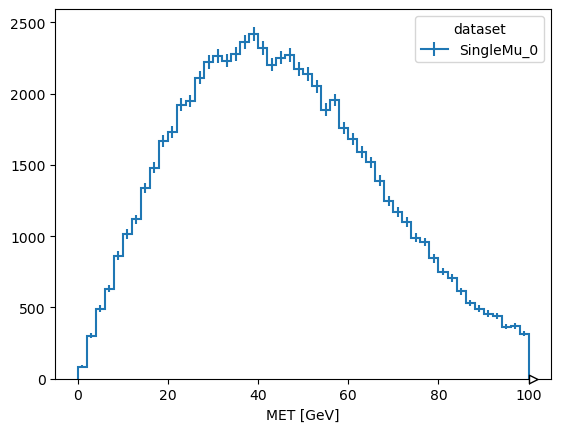

In [1]:
from workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, CustomArtifact, render
from analysis import get_fileset, run_analysis, plot_results, custom_function_remove_last_file

step_fileset = Step(
							        name="Fileset",
							        step_type = Fileset,
							        builder = get_fileset,
                                    builder_params = {"to_print": "\nTEST:\nparameter testing...\nSUCCESS!\n"}
							    )
step_custom_filtering = Step(
						        name="FilesetFiltering",
						        step_type = CustomArtifact,
						        builder = custom_function_remove_last_file,
						    )

step_analysis = Step(
						        name="SingleMuonAnalysis",
						        step_type = Analysis,
						        builder = run_analysis,
						    )

step_plotting = Step(
										name="PlottingMuonAnalysis",
										step_type = Plotting,
										builder = "analysis:plot_results"
								)		
								   
workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_custom_filtering, depends_on=[step_fileset])
workflow.add(step_analysis, depends_on=[step_custom_filtering])
workflow.add(step_plotting, depends_on=[step_analysis])

config = RunConfig(percentage=10, strategy="by_dataset", cache_dir="cache", chunk_fraction=0.3)

result = render(workflow, config)

In [ ]:
result